In [10]:
import os

import torch
import ale_py
import gymnasium as gym

from project.environments import BaseWrapper
from project.agents import DQNAgent
from project.environments.loops import TrainingLoop

FRAMES = 1_000_000
LR = 2.5e-4
DISCOUNT = 0.99
REPLAY_SIZE = 2000
ENVIRONMENT = "ALE/Breakout-v5"
TARGET_UPDATE_FREQUENCY = 10_000
BATCH_SIZE = 32
FINAL_EXPLORATION_FRAME = 1_000_000
REPLAY_START_SIZE = 32

gym.register_envs(ale_py)

device = "cpu"
if torch.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
print(f"Using: {device}")

env = BaseWrapper.create_environment(ENVIRONMENT)

agent = DQNAgent(
    train=True,
    lr=LR,
    discount=DISCOUNT,
    replay_size=REPLAY_SIZE,
    n_actions=env.action_space.n,
    target_update_frequency=TARGET_UPDATE_FREQUENCY,
    batch_size=BATCH_SIZE,
    final_exploration_frame=FINAL_EXPLORATION_FRAME,
    replay_start_size=REPLAY_START_SIZE,
    obs_shape=env.observation_space.shape,
    device=device
)

loop = TrainingLoop(
    env=env,
    agent=agent,
)

Using: mps


In [11]:
s, i = env.reset(seed=42)

In [12]:
agent._dqn((s / 255).unsqueeze(0).to(device))


tensor([[0.0237, 0.0372, 0.0449, 0.0153]], device='mps:0',
       grad_fn=<LinearBackward0>)

In [13]:
agent._target_dqn((s / 255).unsqueeze(0).to(device))

tensor([[0.0237, 0.0372, 0.0449, 0.0153]], device='mps:0',
       grad_fn=<LinearBackward0>)

In [19]:
loop.run(100)

Frames: 100%|██████████| 100/100 [00:00<00:00, 234.33it/s]


In [20]:
s, i = env.reset(seed=42)

In [21]:
agent._dqn((s / 255).unsqueeze(0).to(device))

tensor([[0.0424, 0.0446, 0.0448, 0.0414]], device='mps:0',
       grad_fn=<LinearBackward0>)

In [22]:
agent._target_dqn((s / 255).unsqueeze(0).to(device))

tensor([[0.0237, 0.0372, 0.0449, 0.0153]], device='mps:0',
       grad_fn=<LinearBackward0>)

In [23]:
s, a, r, s_prime, t = agent._memory.sample(32)

In [31]:
import matplotlib.pyplot as plt
i = 20
agent._epsilon

0.9999496000000017

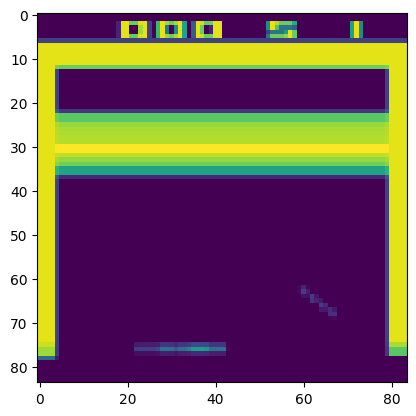

In [32]:
plt.imshow(s[i].mean(dim=0))

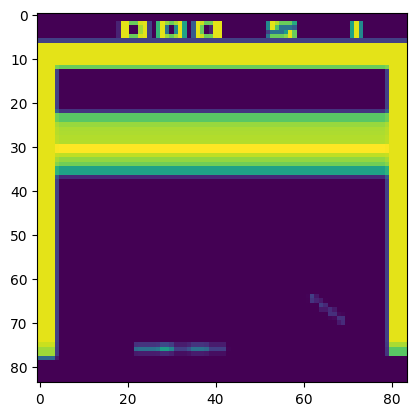

In [33]:
plt.imshow(s_prime[i].mean(dim=0))

In [34]:
t[i], a[i]

(tensor(False), tensor(1, dtype=torch.int32))